# Ablation: price-only vs sentiment-only vs price+sentiment

## Pergunta

O Capítulo 5 estabeleceu que o Transformer + FinBERT não supera um *baseline* XGBoost de 5 *features* de preço sob validação cruzada *expanding-window*. Mas ainda falta uma pergunta fundamental: **o sentimento adiciona *algum* sinal, mesmo que marginal, quando avaliado sob protocolo correto?**

Esta ablação isola a contribuição incremental do sentimento comparando três configurações de *features* treinadas sob o mesmo modelo (XGBoost) e o mesmo protocolo (*expanding-window* 5 *folds*, 5 *seeds*, 3 ativos):

| Configuração | Features | Dim |
|---|---|---:|
| **PRICE** | return, lag_1, lag_5, Volume, std21 | 5 |
| **SENT** | n_articles, mean_logit_pos, mean_logit_neg, mean_logit_neu, mean_sentiment | 5 |
| **PRICE+SENT** | união das duas | 10 |

## Critério de decisão

- **Se PRICE+SENT ≫ PRICE** → sentimento adiciona sinal real
- **Se PRICE+SENT ≈ PRICE** → sentimento não adiciona nada (confirma achado do Cap. 5)
- **Se SENT ≈ 0.5** → sentimento sozinho não é preditivo
- **Se SENT > 0.5 mas PRICE+SENT ≈ PRICE** → sentimento é preditivo mas redundante com preço

Este experimento é o último que fecha definitivamente a contribuição do sentimento no *pipeline* atual.

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import xgboost as xgb
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from eval_utils import make_binary_target

HORIZON = 21
MIN_TRAIN_DAYS = 600
VAL_DAYS = 90
TEST_DAYS = 90
STEP_DAYS = 90
N_SEEDS = 5

TICKERS = {
    'ITUB4': ('ITUB4.SA', '../4.finbert-br/itub4_daily_sentiment.csv'),
    'PETR4': ('PETR4.SA', '../4.finbert-br/petr4_daily_sentiment.csv'),
    'VALE3': ('VALE3.SA', '../4.finbert-br/vale3_daily_sentiment.csv'),
}

PRICE_FEATURES = ['return','lag_1','lag_5','Volume','std21']
SENT_FEATURES  = ['n_articles','mean_logit_pos','mean_logit_neg','mean_logit_neu','mean_sentiment']
CONFIGS = {
    'PRICE':       PRICE_FEATURES,
    'SENT':        SENT_FEATURES,
    'PRICE+SENT':  PRICE_FEATURES + SENT_FEATURES,
}
PRICE_COLS = ['Close','Volume','return','ma7','ma21','std21','lag_1','lag_2','lag_3','lag_4','lag_5']

In [2]:
def load_prices(yf_ticker, period='5y'):
    df = yf.Ticker(yf_ticker).history(period=period, auto_adjust=True).reset_index()
    df['date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
    df = df[['date','Close','Volume']].copy()
    df['return'] = df['Close'].pct_change()
    df['ma7']    = df['Close'].rolling(7).mean()
    df['ma21']   = df['Close'].rolling(21).mean()
    df['std21']  = df['Close'].rolling(21).std()
    for k in range(1, 6):
        df[f'lag_{k}'] = df['Close'].shift(k)
    return df.dropna().reset_index(drop=True)

def build_dataset(yf_ticker, sentiment_csv):
    px = load_prices(yf_ticker)
    sent = pd.read_csv(sentiment_csv, parse_dates=['date'])[['date'] + SENT_FEATURES]
    df = px.merge(sent, on='date', how='left').sort_values('date').reset_index(drop=True)
    df[SENT_FEATURES] = df[SENT_FEATURES].ffill().fillna(0)
    df['target'] = make_binary_target(df['Close'], horizon=HORIZON)
    return df.dropna(subset=['target']).reset_index(drop=True)

def expanding_folds(n_total, min_train=MIN_TRAIN_DAYS, val=VAL_DAYS, test=TEST_DAYS, step=STEP_DAYS):
    folds = []
    train_end = min_train
    while train_end + val + test <= n_total:
        folds.append((train_end, train_end + val, train_end + val + test))
        train_end += step
    return folds

def train_xgb(df, fold, feats, seed):
    train_end, val_end, test_end = fold
    tr = df.iloc[:train_end]; va = df.iloc[train_end:val_end]; te = df.iloc[val_end:test_end]
    if len(np.unique(te['target'])) < 2: return None
    sc = StandardScaler().fit(tr[feats])
    Xtr = sc.transform(tr[feats]); ytr = tr['target'].values.astype(int)
    Xva = sc.transform(va[feats]); yva = va['target'].values.astype(int)
    Xte = sc.transform(te[feats]); yte = te['target'].values.astype(int)
    pos = (ytr==1).sum(); neg = (ytr==0).sum()
    m = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg/max(pos,1), eval_metric='auc', random_state=seed,
    )
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return {
        'auc': roc_auc_score(yte, m.predict_proba(Xte)[:,1]),
        'train_balance': float(tr['target'].mean()),
        'test_balance':  float(te['target'].mean()),
    }

## Loop principal: 3 ativos × 5 folds × 3 configs × 5 seeds

In [3]:
rows = []
t0 = time.time()
for ticker, (yf_t, sent_csv) in TICKERS.items():
    print(f'\n=== {ticker} ===')
    df = build_dataset(yf_t, sent_csv)
    folds = expanding_folds(len(df))
    print(f'  {len(df)} dias | {len(folds)} folds')
    for fi, fold in enumerate(folds):
        for seed in range(N_SEEDS):
            for cfg_name, feats in CONFIGS.items():
                r = train_xgb(df, fold, feats, seed)
                if r is None: continue
                r.update({'ticker': ticker, 'config': cfg_name, 'fold': fi, 'seed': seed})
                rows.append(r)
    print(f'  done | {time.time()-t0:.0f}s')

results = pd.DataFrame(rows)
results.to_csv('results_ablation.csv', index=False)
print(f'\nTotal: {len(results)} runs in {time.time()-t0:.0f}s')


=== ITUB4 ===


  1207 dias | 5 folds


  done | 77s

=== PETR4 ===


  1207 dias | 5 folds


  done | 119s

=== VALE3 ===


  1207 dias | 5 folds


  done | 137s

Total: 225 runs in 137s


## Agregação

In [4]:
agg = results.groupby(['ticker','config']).agg(
    auc_mean=('auc','mean'), auc_std=('auc','std'),
    auc_median=('auc','median'),
    n_runs=('auc','count'),
).round(3)
print(agg.to_string())
agg.to_csv('ablation_summary.csv')

print('\n--- Média global sobre 3 ativos ---')
global_mean = results.groupby('config')['auc'].agg(['mean','std','median']).round(3)
print(global_mean.to_string())

                   auc_mean  auc_std  auc_median  n_runs
ticker config                                           
ITUB4  PRICE          0.684    0.062       0.710      25
       PRICE+SENT     0.651    0.072       0.661      25
       SENT           0.436    0.067       0.399      25
PETR4  PRICE          0.692    0.187       0.803      25
       PRICE+SENT     0.676    0.178       0.792      25
       SENT           0.494    0.046       0.478      25
VALE3  PRICE          0.609    0.107       0.568      25
       PRICE+SENT     0.667    0.129       0.733      25
       SENT           0.510    0.047       0.524      25

--- Média global sobre 3 ativos ---
             mean    std  median
config                          
PRICE       0.662  0.133   0.706
PRICE+SENT  0.665  0.132   0.692
SENT        0.480  0.062   0.492


In [5]:
# Teste pareado: PRICE+SENT vs PRICE (a pergunta central)
paired = results.groupby(['ticker','fold','seed']).apply(lambda g: pd.Series({
    'PRICE':      g[g.config=='PRICE']['auc'].iloc[0]      if (g.config=='PRICE').any() else np.nan,
    'SENT':       g[g.config=='SENT']['auc'].iloc[0]       if (g.config=='SENT').any() else np.nan,
    'PRICE+SENT': g[g.config=='PRICE+SENT']['auc'].iloc[0] if (g.config=='PRICE+SENT').any() else np.nan,
})).dropna().reset_index()

delta = paired['PRICE+SENT'] - paired['PRICE']
print(f'PRICE+SENT − PRICE sobre {len(paired)} pares:')
print(f'  mean Δ = {delta.mean():+.4f}')
print(f'  std Δ  = {delta.std():.4f}')
print(f'  pares onde PRICE+SENT > PRICE: {(delta > 0).sum()}/{len(delta)}')
if len(delta) >= 5:
    stat, p = wilcoxon(delta)
    print(f'  Wilcoxon W={stat:.1f} p={p:.4f}')

rng = np.random.default_rng(42)
boot = [delta.iloc[rng.integers(0,len(delta),len(delta))].mean() for _ in range(2000)]
lo, hi = np.quantile(boot, [0.025, 0.975])
print(f'  95% bootstrap CI: [{lo:+.4f}, {hi:+.4f}] | inclui zero? {"SIM" if lo <= 0 <= hi else "NÃO"}')

PRICE+SENT − PRICE sobre 75 pares:
  mean Δ = +0.0028
  std Δ  = 0.0659
  pares onde PRICE+SENT > PRICE: 32/75
  Wilcoxon W=1295.5 p=0.4941


  95% bootstrap CI: [-0.0117, +0.0184] | inclui zero? SIM


/tmp/ipykernel_389109/142763633.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  paired = results.groupby(['ticker','fold','seed']).apply(lambda g: pd.Series({


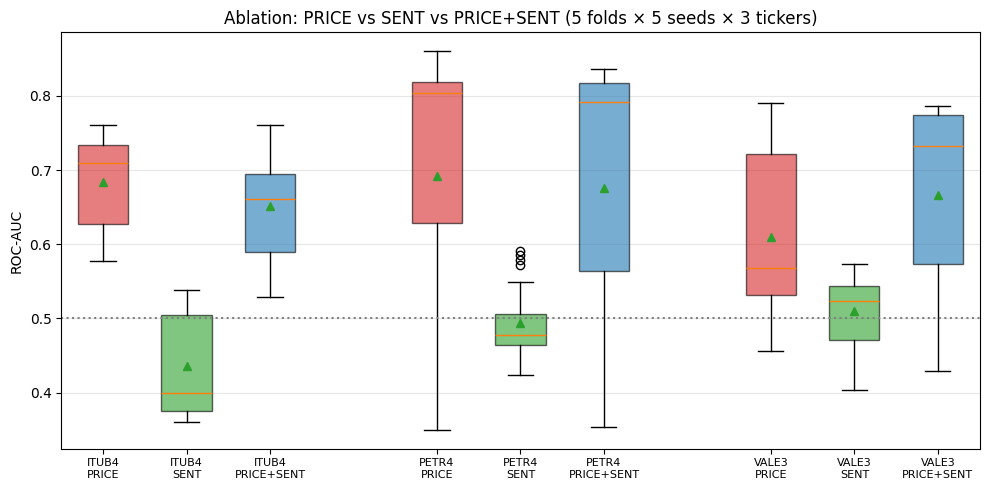

In [6]:
# Visualização: boxplot por ticker × config
fig, ax = plt.subplots(figsize=(10, 5))
positions = []; labels = []; data = []
colors = {'PRICE':'C3','SENT':'C2','PRICE+SENT':'C0'}
for i, ticker in enumerate(TICKERS.keys()):
    for j, cfg in enumerate(['PRICE','SENT','PRICE+SENT']):
        sub = results[(results.ticker==ticker) & (results.config==cfg)]['auc']
        positions.append(i*4 + j)
        labels.append(f'{ticker}\n{cfg}')
        data.append(sub.values)
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True, showmeans=True)
for patch, lbl in zip(bp['boxes'], labels):
    cfg = lbl.split('\n')[1]
    patch.set_facecolor(colors[cfg]); patch.set_alpha(0.6)
ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=8)
ax.axhline(0.5, ls=':', color='gray', label='Acaso')
ax.set_ylabel('ROC-AUC')
ax.set_title('Ablation: PRICE vs SENT vs PRICE+SENT (5 folds × 5 seeds × 3 tickers)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ablation_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()

## Interpretação

Os três números a reportar no Chapter 5:

1. **AUC médio de PRICE** sobre os 3 ativos — o piso autoregressivo
2. **AUC médio de SENT** — o quanto o sentimento sozinho consegue
3. **AUC médio de PRICE+SENT** — o efeito combinado

Se `PRICE+SENT − PRICE` é ≈ 0 com CI contendo zero e p Wilcoxon > 0.05, o sentimento adiciona **exatamente nada** ao *baseline* de preço, fechando definitivamente a narrativa do Cap. 5.